Descifrando la industria de los videojuegos


Este proyecto busca detectar patrones que permitan anticipar si un videojuego tendrá éxito o no, con el fin de apoyar la planificación de futuras estrategias publicitarias. El estudio se realizó por regiones incluyendo América del Norte, Europa, Japón y otras zonas y abarcó distintas plataformas, como Wii, Xbox 360 y las diferentes versiones de PlayStation hasta la versión 6.

En términos generales, los resultados muestran que:

- Tomar en cuenta las particularidades del mercado objetivo es fundamental, ya que cada región presenta comportamientos y dinámicas distintas.

- Desarrollar un videojuego acorde a los géneros más demandados en ese mercado puede influir notablemente en su desempeño. Asimismo, la plataforma elegida juega un papel relevante.

- No obstante, al analizar las plataformas, también es importante considerar el año de lanzamiento, ya que este puede afectar cuál domina en ventas.

- Por último, no se observa una relación clara entre las calificaciones de los críticos y las ventas, por lo que este factor no resulta decisivo.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [5]:
games = pd.read_csv("games.csv")

games

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [6]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [7]:
games.rename(columns=str.lower, inplace=True)

In [8]:
print("Columnas en minusculas:")

games.columns

Columnas en minusculas:


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [9]:
print(f"Filas completas duplicadas: {games.duplicated().sum()}")

Filas completas duplicadas: 0


In [10]:
print("Lista de valores ausentes por columna")

games.isna().sum()

Lista de valores ausentes por columna


name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [11]:
games["year_of_release"] = games["year_of_release"].astype("Int64")
games["critic_score"] = games["critic_score"].astype("Int64")
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')

games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   Int64  
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(2), float64(5), object(4)
memory usage: 1.4+ MB


In [12]:
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

El tipo de dato de 3 columnas en especifico fueron cambiados ("year_of_release"; "critic_score" y "user_score") debido a mejor organizacion visual, ya que estaban en decimales cuando no es necesario y puede resultar confuso en el analisis del mismo, aparte de ser una representacion logica. En la columna "user_score" fue necesario usar el metodo "pd.to_numeric()", para asi cambiar los datos decimales que estaban en tipo "object" de manera precisa y los valores que no fueran numeros, automaticamente se sustituyeran por valores ausentes.

In [13]:
print("Eliminacion de valores ausentes")

Eliminacion de valores ausentes


In [14]:
#NAME
games[games["name"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,<NA>,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,<NA>,NaN,NaN


In [15]:
games = games.dropna(subset=["name"]).copy()

In [16]:
games["name"].isna().sum()

np.int64(0)

En la columna "name" se pueden eliminar las filas completas, ya que tiene valores irrelevantes en cuanto a como perjudicaria si las elimino, ademas de que son dos filas.

In [17]:
#YEAR OF RELEASE

# ¿Hay algún patrón en los juegos sin año?
games_sin_año = games[games["year_of_release"].isna()]

games_sin_año

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,<NA>,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,<NA>,Sports,0.01,0.00,0.00,0.00,43,NaN,E10+
16405,Freaky Flyers,GC,<NA>,Racing,0.01,0.00,0.00,0.00,69,6.5,T
16448,Inversion,PC,<NA>,Shooter,0.01,0.00,0.00,0.00,59,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,<NA>,NaN,NaN


In [18]:
porcentaje_ausentes = (269 / len(games)) * 100
print(f"Porcentaje de valores ausentes: {porcentaje_ausentes:}%")

Porcentaje de valores ausentes: 1.6095255190570215%


In [19]:
print("Número de plataformas unicas de los juegos sin año:", games_sin_año["platform"].nunique())

print("Plataformas más comunes sin año:")
games_sin_año["platform"].value_counts().head(10)

Número de plataformas unicas de los juegos sin año: 16
Plataformas más comunes sin año:


platform
PS2     34
Wii     34
X360    30
DS      30
PS3     25
XB      21
2600    17
PC      17
PSP     16
GC      14
Name: count, dtype: int64

In [20]:
print("Número de plataformas únicas del dataframe orginal:", games['platform'].nunique())

print("\nPrimeras 10 plataformas con mas juegos:")
games['platform'].value_counts().head(10)

Número de plataformas únicas del dataframe orginal: 31

Primeras 10 plataformas con mas juegos:


platform
PS2     2161
DS      2151
PS3     1331
Wii     1320
X360    1262
PSP     1209
PS      1197
PC       974
XB       824
GBA      822
Name: count, dtype: int64

In [21]:
# Analizar el rango de años para cada plataforma (solo datos con año disponible)
platform_years_notna = games[games['year_of_release'].notna()].groupby('platform')['year_of_release'].agg(["min", "max", "count"]).reset_index()

platform_years_notna.columns = ["platform", "min_year", "max_year", "games_total"]

platform_years_notna['range_years'] = platform_years_notna['max_year'] - platform_years_notna['min_year']

platform_years_notna.head()

,platform,min_year,max_year,games_total,range_years
0,2600,1980,1989,116,9
1,3DO,1994,1995,3,1
2,3DS,2011,2016,512,5
3,DC,1998,2008,52,10
4,DS,1985,2013,2121,28


In [22]:
# Ordenar por total de juegos para ver las plataformas más populares primero
print("Rango de años por plataforma (ordenado por popularidad):")

platform_years_notna.sort_values('games_total', ascending=False).head()

Rango de años por plataforma (ordenado por popularidad):


,platform,min_year,max_year,games_total,range_years
16,PS2,2000,2011,2127,11
4,DS,1985,2013,2121,28
17,PS3,2006,2016,1306,10
26,Wii,2006,2016,1286,10
28,X360,2005,2016,1232,11


In [23]:
# Ver las plataformas con más años de duración
print("PLATAFORMAS CON MÁS AÑOS DE DURACIÓN")
platform_years_notna.sort_values("range_years", ascending=False).head()

PLATAFORMAS CON MÁS AÑOS DE DURACIÓN


,platform,min_year,max_year,games_total,range_years
13,PC,1985,2016,957,31
4,DS,1985,2013,2121,28
5,GB,1988,2001,97,13
11,NES,1983,1994,98,11
28,X360,2005,2016,1232,11


In [24]:
print("PLATAFORMAS CON MENOS AÑOS DE DURACIÓN")
platform_years_notna.sort_values('range_years').head()

PLATAFORMAS CON MENOS AÑOS DE DURACIÓN


,platform,min_year,max_year,games_total,range_years
14,PCFX,1996,1996,1,0
9,GG,1992,1992,1,0
24,TG16,1995,1995,2,0
1,3DO,1994,1995,3,1
22,SCD,1993,1994,6,1


In [25]:
#DEJAMOS LOS VALORES AUSENTES PARA FUTUROS ANALISIS
games["year_of_release"].isna().sum()

np.int64(269)

DESPUES DEL ANALISIS PROFUNDO SOBRE LOS JUEGOS QUE NO TIENEN AÑO; ADEMAS DE COMPRENDER SI TIENEN ALGUN TIPO DE SIGNIFICADO QUE INFLUYA POR LA PLATAFORMA. PUEDO CONCLUIR QUE SIENDO TAN POCOS VALORES EN COMPARACION AL TOTAL, NO AFECTARA PRACTICAMENTE EN NADA SI LOS DEJO NULOS O AUSENTES, DE HECHO ME PODRIAN PERJUDICAR PARA FUTUROS ANALISIS SI ESOS VALORES LOS SUSTITUYO POR VALORES NUMERICOS, YA QUE EL VALOR MINIMO DE FECHAS POR PLATAFORMA SIEMPRE ME SALDRIA "0" SI ES QUE QUIERO SABER EL AÑO DE LANZAMIENTO MINIMO DE CADA PLATAFORMA, Y SI ES QUE REALMENTE LOS CAMBIO POR "0". AL DEJARLOS AUSENTES O NULOS NO PERJUDICARIA EN ALGUNA FORMA.

AUNQUE SEAN SOLAMENTE 269 VALORES AUSENTES DE LOS 16713 VALORES PRESNETES QUE HAY, ES IMPORTANTE GUARDAR CIERTOS DATOS QUE INFLUYEN EN LA MEDIA U OTRO FACTOR QUE AFECTE EL RESULTADO TOTAL DE ALGUNA COLUMNA DE "games", POR LO QUE CONSIDERO, POR SI ACASO, SI ES QUE INFLUYE EN EL ANALISIS MAS ADELANTE; DEJARLOS AUSENTES O NULOS.

In [26]:
#CRITIC_SCORE
games["critic_score"].value_counts(dropna=False).head()

critic_score
<NA>    8576
70       256
71       254
75       245
78       240
Name: count, dtype: Int64

In [27]:
games["critic_score"].describe()

count       8137.0
mean     68.967679
std      13.938165
min           13.0
25%           60.0
50%           71.0
75%           79.0
max           98.0
Name: critic_score, dtype: Float64

In [28]:
games["critic_score"].nunique()

82

In [29]:
critic_score_na = games[games["critic_score"].isna()]

In [30]:
critic_score_na

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,<NA>,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,<NA>,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,<NA>,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,<NA>,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,<NA>,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,<NA>,NaN,NaN


In [31]:
critic_score_na["platform"].value_counts().head()

platform
DS     1434
PS      997
PS2     863
PSP     747
Wii     735
Name: count, dtype: int64

In [32]:
critic_score_na["year_of_release"].value_counts().head()

year_of_release
2009    775
2010    755
2008    712
2011    636
2007    505
Name: count, dtype: Int64

In [33]:
games.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64

Los juegos que no tuvieron calificacion critica de acuerdo al año, infiere a que son juegos de una epoca en especifico. No son tan viejos pero tampoco tan nuevos; esa epoca esta entre 2007 y 2011, por lo que se podria intuir que no hubo calificacion criticas porque no son juegos de años recientes, aparte de que podria influir por la plataforma o porque no alcanzaron un numero conveniente de ventas en general.

Las plataformas que contienen mas juegos con valores ausentes en "critic_score", se puede inferir a que son plataformas retro, mas no las mas viejas; eso puede influir en que no se haya tomado en cuenta la necesidad de calificarlos criticamente, sin descartar el hecho de que tambien pueden ser juegos mas independientes, por lo que no se invirtio mucho dinero, de parte de compañias con bajo prestigio como para tener tantas ventas.

Dichos valores ausentes no se sustituiran, debido a que si les asigno un valor de "0" por ejemplo, la media bajara muchisimo de lo que realmente es, ya que aproximadamente la mitad de valores de "critic_score" son ausentes. En proporcion a la cantidad de juegos que hay, muchos se considerarian en "0" y ese valor si perjudicaria la media en general de "critic_score", por lo que es necesaria contarlos como valores que no perjudican en nada, osea NEUTROS; en conclusion los dejo como valores ausentes.

In [34]:
#USER SCORE
games["user_score"].value_counts(dropna=False)

user_score
NaN    9123
7.8     324
8.0     290
8.2     282
8.3     254
       ... 
1.3       2
1.0       2
0.9       2
0.0       1
9.7       1
Name: count, Length: 96, dtype: int64

In [35]:
user_score_na = games[games["user_score"].isna()]

user_score_na

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,<NA>,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,<NA>,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,<NA>,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,<NA>,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,<NA>,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,<NA>,NaN,NaN


In [36]:
user_score_na["critic_score"].isna().sum()

np.int64(8003)

In [37]:
user_score_na["rating"].isna().sum()

np.int64(6678)

In [38]:
#RATING
games["rating"].value_counts(dropna=False)

rating
NaN     6764
E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: count, dtype: int64

In [39]:
rating_na = games[games["rating"].isna()]

rating_na

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,<NA>,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,<NA>,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,<NA>,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,<NA>,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,<NA>,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,<NA>,NaN,NaN


In [40]:
rating_na["user_score"].isna().sum()

np.int64(6678)

In [41]:
rating_na["critic_score"].isna().sum()

np.int64(6681)

Mediante el filtrado de la columna "user_score", pude darme cuenta que la mayoria de valores ausentes de"critic_score" van de acuerdo a los valores ausentes de "user_score" y lo mismo pasa con la columna de "rating". Los valores ausentes de las 3 columnas van de acuerdo a la lista de juegos que no se tomaron en cuenta para estas 3 clasificaciones; por lo menos la inmensa mayoria.

No se sustituiran los valores ausentes de las 3 columnas, se quedaran ausentes para que no sesguen los datos de alguna forma.

In [42]:
#SUMA DE VENTAS TOTALES DE TODAS LAS REGIONES POR JUEGO

In [43]:
games["total_sales"] = games["na_sales"] + games["eu_sales"] + games["jp_sales"] + games["other_sales"]

In [44]:
games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,NaN,31.38


In [45]:
#PASO 3
# Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

games_year_release = games.groupby("year_of_release")["name"].count().reset_index()

games_year_release

,year_of_release,name
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


Los años con mayor cantidad de juegos lanzados estan alrededor de 2006 y 2011

<Axes: title={'center': 'Juegos lanzados por año'}, xlabel='Año de lanzamiento', ylabel='Juegos'>

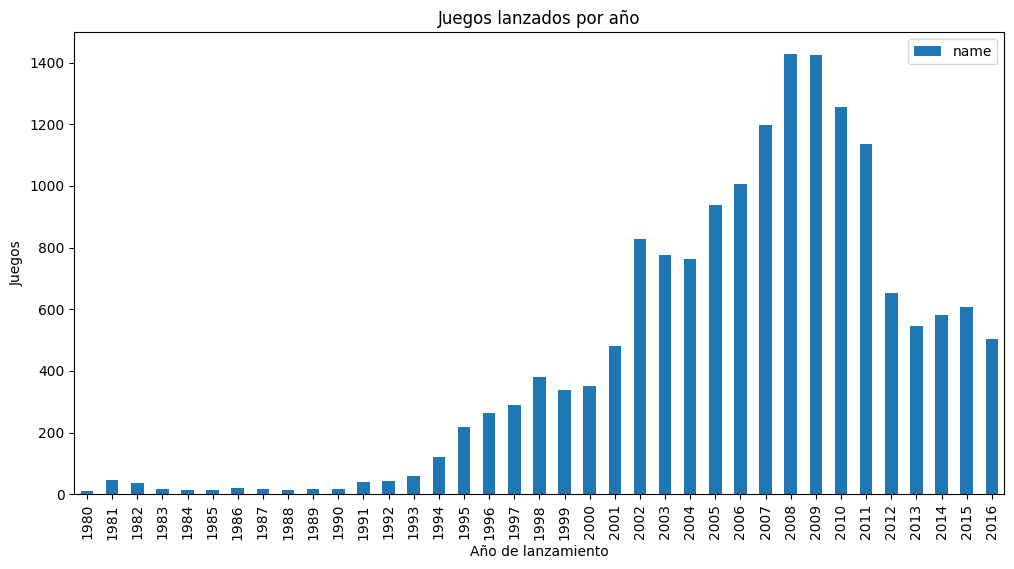

In [46]:
games_year_release.plot(kind="bar", figsize=(12, 6), x="year_of_release", y= "name",
                        title="Juegos lanzados por año", xlabel="Año de lanzamiento", ylabel= "Juegos")

In [47]:
# Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año.

top_platforms_sales = games.groupby("platform")["total_sales"].sum().reset_index().sort_values("total_sales", ascending=False)

In [48]:
top_platforms_sales.head(10)

,platform,total_sales
16,PS2,1255.77
28,X360,971.42
17,PS3,939.65
26,Wii,907.51
4,DS,806.12
15,PS,730.86
6,GBA,317.85
18,PS4,314.14
19,PSP,294.05
13,PC,259.52


In [49]:
platform_years = games.groupby('platform')['year_of_release'].agg(["min", "max", "count"]).reset_index()

platform_years.columns = ["platform", "min_year", "max_year", "games_total"]

platform_years['range_years'] = platform_years['max_year'] - platform_years['min_year']

platform_years.sort_values("range_years", ascending=False).head(10)

,platform,min_year,max_year,games_total,range_years
13,PC,1985,2016,957,31
4,DS,1985,2013,2121,28
5,GB,1988,2001,97,13
11,NES,1983,1994,98,11
28,X360,2005,2016,1232,11
19,PSP,2004,2015,1193,11
16,PS2,2000,2011,2127,11
17,PS3,2006,2016,1306,10
3,DC,1998,2008,52,10
26,Wii,2006,2016,1286,10


In [50]:
platforms_merge = top_platforms_sales.merge(platform_years, on="platform")

platforms_merge

,platform,total_sales,min_year,max_year,games_total,range_years
0,PS2,1255.77,2000,2011,2127,11
1,X360,971.42,2005,2016,1232,11
2,PS3,939.65,2006,2016,1306,10
3,Wii,907.51,2006,2016,1286,10
4,DS,806.12,1985,2013,2121,28
5,PS,730.86,1994,2003,1190,9
6,GBA,317.85,2000,2007,811,7
7,PS4,314.14,2013,2016,392,3
8,PSP,294.05,2004,2015,1193,11
9,PC,259.52,1985,2016,957,31


In [51]:
# Busca las plataformas que solían ser populares pero que ahora no tienen ventas.
#¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

periodo_temprano = games[games["year_of_release"] <= 2008]
periodo_tardio = games[games["year_of_release"] > 2008]

print("Período temprano: 1980-2008")
print("Período tardío: 2009-2016")

Período temprano: 1980-2008
Período tardío: 2009-2016


In [52]:
ventas_temprano = periodo_temprano.groupby("platform")["total_sales"].sum().reset_index()

ventas_temprano.columns = ["platform", "ventas_antes_2008"]

ventas_temprano.sort_values("ventas_antes_2008", ascending=False)

,platform,ventas_antes_2008
15,PS2,1201.07
14,PS,727.58
3,DS,559.49
23,Wii,461.24
5,GBA,312.88
24,X360,290.54
4,GB,254.43
25,XB,251.57
10,NES,251.05
9,N64,218.01


In [53]:
ventas_tardio = periodo_tardio.groupby("platform")["total_sales"].sum().reset_index()

ventas_tardio.columns = ["platform", "ventas_despues_2009"]

ventas_tardio.sort_values("ventas_despues_2009", ascending=False)

,platform,ventas_despues_2009
4,PS3,718.67
10,X360,670.70
8,Wii,429.94
5,PS4,314.14
0,3DS,257.81
1,DS,243.29
11,XOne,159.32
2,PC,138.87
6,PSP,101.83
9,WiiU,82.19


In [54]:
# Combinar las ventas de ambos períodos
analisis_ciclo = ventas_temprano.merge(ventas_tardio, on="platform", how="outer")

# Llenar valores ausentes con 0
analisis_ciclo = analisis_ciclo.fillna(0)

# Solo calcular la diferencia
analisis_ciclo["diferencia"] = analisis_ciclo["ventas_antes_2008"] - analisis_ciclo["ventas_despues_2009"]

analisis_ciclo

,platform,ventas_antes_2008,ventas_despues_2009,diferencia
0,2600,86.48,0.00,86.48
1,3DO,0.10,0.00,0.10
2,3DS,0.00,257.81,-257.81
3,DC,15.95,0.00,15.95
4,DS,559.49,243.29,316.20
5,GB,254.43,0.00,254.43
6,GBA,312.88,0.00,312.88
7,GC,196.73,0.00,196.73
8,GEN,28.35,0.00,28.35
9,GG,0.04,0.00,0.04


In [55]:
#¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen?
# Elige varias plataformas potencialmente rentables.

In [56]:
# Filtrar plataformas que fueron populares antes pero ahora no tienen ventas
plataformas_extintas = analisis_ciclo[
    (analisis_ciclo["ventas_antes_2008"] > 50) &  # Fueron populares (más de 50M en ventas)
    (analisis_ciclo["ventas_despues_2009"] < 10)      # Ahora casi no venden (menos de 10M)
].sort_values("ventas_antes_2008", ascending=False)

print("Plataformas que fueron populares pero 'murieron':")
plataformas_extintas

Plataformas que fueron populares pero 'murieron':


,platform,ventas_antes_2008,ventas_despues_2009,diferencia
15,PS,727.58,0.0,727.58
6,GBA,312.88,0.0,312.88
5,GB,254.43,0.0,254.43
29,XB,251.57,0.0,251.57
11,NES,251.05,0.0,251.05
10,N64,218.01,0.0,218.01
23,SNES,200.04,0.0,200.04
7,GC,196.73,0.0,196.73
0,2600,86.48,0.0,86.48


In [57]:
# Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma.
# ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

platform_sales_difference = platforms_merge.merge(plataformas_extintas, how="outer", on="platform")

platform_sales_difference = platform_sales_difference.fillna(0)

platform_sales_difference

,platform,total_sales,min_year,max_year,games_total,range_years,ventas_antes_2008,ventas_despues_2009,diferencia
0,2600,96.98,1980,1989,116,9,86.48,0.0,86.48
1,3DO,0.10,1994,1995,3,1,0.00,0.0,0.00
2,3DS,259.00,2011,2016,512,5,0.00,0.0,0.00
3,DC,15.95,1998,2008,52,10,0.00,0.0,0.00
4,DS,806.12,1985,2013,2121,28,0.00,0.0,0.00
5,GB,255.46,1988,2001,97,13,254.43,0.0,254.43
6,GBA,317.85,2000,2007,811,7,312.88,0.0,312.88
7,GC,198.93,2001,2007,542,6,196.73,0.0,196.73
8,GEN,28.35,1990,1994,27,4,0.00,0.0,0.00
9,GG,0.04,1992,1992,1,0,0.00,0.0,0.00


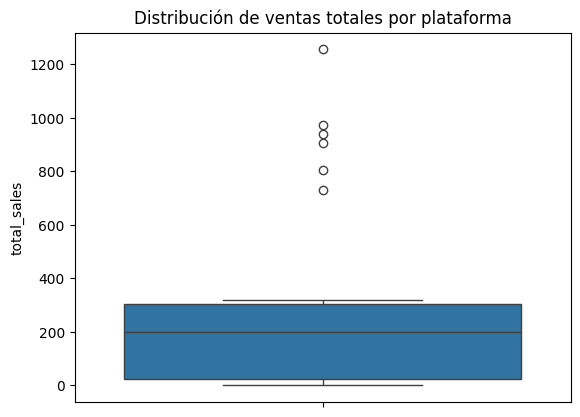

In [58]:
sns.boxplot(data=platform_sales_difference, y="total_sales")
plt.title("Distribución de ventas totales por plataforma")
plt.show()

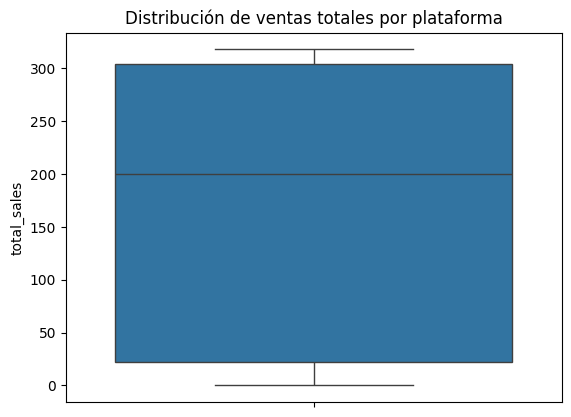

In [59]:
sns.boxplot(data=platform_sales_difference, y="total_sales", showfliers = False)
plt.title("Distribución de ventas totales por plataforma")
plt.show()

In [60]:
platform_sales_difference.describe()

,total_sales,min_year,max_year,games_total,range_years,ventas_antes_2008,ventas_despues_2009,diferencia
count,31.000000,31.0,31.0,31.0,31.0,31.000000,31.0,31.000000
mean,287.525484,1997.645161,2005.258065,530.451613,7.612903,80.605484,0.0,80.605484
std,348.220029,9.094131,9.273503,617.367467,6.998464,158.179858,0.0,158.179858
min,0.030000,1980.0,1989.0,1.0,0.0,0.000000,0.0,0.000000
25%,22.150000,1992.5,1996.0,39.5,3.0,0.000000,0.0,0.000000
50%,200.040000,1996.0,2007.0,247.0,6.0,0.000000,0.0,0.000000
75%,304.095000,2004.5,2016.0,884.0,10.0,141.605000,0.0,141.605000
max,1255.770000,2013.0,2016.0,2127.0,31.0,727.580000,0.0,727.580000


Existe gran diferencia sobre ciertos juegos que alcanzaron gran exito de ventas; los cuales se consideran los valores atipicos del boxplot. La media sin embargo es de 287 millones cuando el valor maximo es de 1255 millones, por lo que es muy grande la diferencia del promedio. Las consolas mas populares y que todos conocemos establecen ser las unicas que cumplen con las expectativas de los clientes, debido a que superaron con creces las ventas totales de juegos de otras plataformas que estan conforme a la media.

La media se dispara bastante a diferencia de la mediana por el sesgo que crean los valores atipicos ya mecionados

In [61]:
# Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección).

xbox_360_data = games[games["platform"] == "X360"]

xbox_360_data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,61,6.3,E,21.82
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97,8.1,M,16.27
29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88,3.4,M,14.73
32,Call of Duty: Black Ops,X360,2010,Shooter,9.70,3.68,0.11,1.13,87,6.3,M,14.62
35,Call of Duty: Black Ops II,X360,2012,Shooter,8.25,4.24,0.07,1.12,83,4.8,M,13.68
...,...,...,...,...,...,...,...,...,...,...,...,...
16613,Dragon Ball Z for Kinect,X360,2012,Fighting,0.01,0.00,0.00,0.00,49,2.1,T,0.01
16622,World Snooker Championship 2007,X360,2007,Sports,0.00,0.01,0.00,0.00,<NA>,NaN,NaN,0.01
16647,Metal Gear Solid HD Edition,X360,2011,Action,0.00,0.00,0.01,0.00,<NA>,NaN,M,0.01
16654,Ben 10 Omniverse 2,X360,2013,Action,0.00,0.01,0.00,0.00,<NA>,5.1,E10+,0.01


Text(0.5, 1.0, 'Relacion entre critic score y total sales')

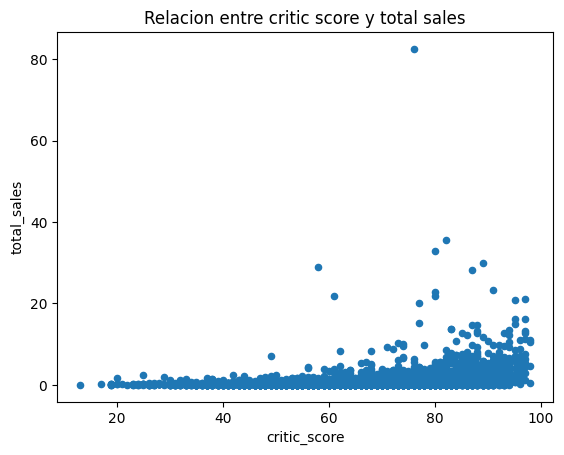

In [62]:
#Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

critic_score = games[games["critic_score"].notna()]

critic_score.plot.scatter(x="critic_score", y="total_sales")
plt.title("Relacion entre critic score y total sales")

Text(0.5, 1.0, 'Relacion entre user score y total sales')

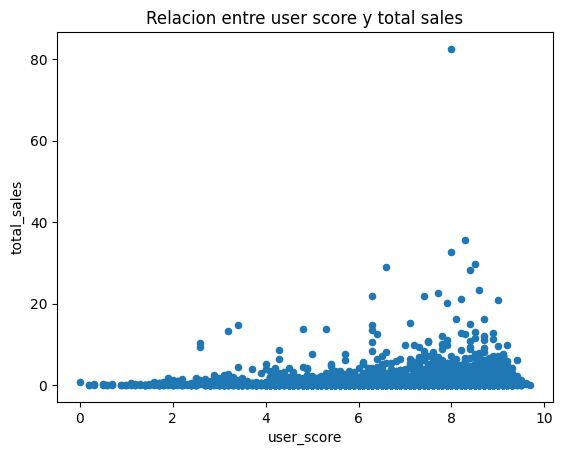

In [63]:
user_score = games[games["user_score"].notna()]

user_score.plot.scatter(x="user_score", y="total_sales")
plt.title("Relacion entre user score y total sales")

Se puede ver claramente que entre mas puntuacion de critica tengan los juegos, sesgan a mas altas ventas totales. Los valores de ventas totales del grafico de "critic_score", sesgan mas hacia la derecha, por lo que infiere que entre mas puntuacion alta critica, mas cotizados y vendidos seran esos juegos.

Se aprecia que los valores de "user_score" de ventas totales tambien sesgan a la derecha, de diferente forma a como se representan con "critic_score". Muchos de los juegos de calificaciones de usuarios altas no necesariamente tienen ventan que destaquen, de hecho muchos de ellos que obtuvieron entre 9 y 10 de "user_score" tienen menos de 20 millones de ventas totales, habiendo juegos de entre 6 a 8 de "user_score" que superan facilmente los 20 millomnes en ventas totales. Significa que no necesariamente que la mas alta calificacion de usuario hara que sea de los mas cotizados para los usuarios en general.

Los juegos con valores ausentes de parte de calificaciones de usuarios y de criticos son muy importantes en relacion con la cantidad de ventas totales que se obtengan de esos juegos. Se aprecia la manera en la que los juegos con valores ausentes en "user_score" y "critic_score" de la plataforma de "xbox360" no tiene casi ventas en comparacion a los juegos que si tiene califacion critica y de usuario. En definicion, los juegos con valores ausentes en calificaciones, afecta de manera alarmante las ventas totales de dichos juegos.

In [64]:
# Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

juegos_multiplataforma = games.groupby("name").agg({
    "platform": "count",
    "total_sales": "sum"
}).reset_index()

juegos_multiplataforma

,name,platform,total_sales
0,Beyblade Burst,1,0.03
1,Fire Emblem Fates,1,1.67
2,Frozen: Olaf's Quest,2,1.10
3,Haikyu!! Cross Team Match!,1,0.04
4,Tales of Xillia 2,1,0.84
...,...,...,...
11554,thinkSMART: Chess for Kids,1,0.01
11555,uDraw Studio,1,2.42
11556,uDraw Studio: Instant Artist,2,0.19
11557,wwe Smackdown vs. Raw 2006,1,3.00


In [65]:
juegos_populares = juegos_multiplataforma[juegos_multiplataforma["platform"] >= 3
    ].sort_values("total_sales", ascending=False)

print("Top 10 juegos multiplataforma:")
juegos_populares.head(10)

Top 10 juegos multiplataforma:


,name,platform,total_sales
3742,Grand Theft Auto V,5,56.58
1241,Call of Duty: Black Ops,5,30.82
1248,Call of Duty: Modern Warfare 3,4,30.60
1243,Call of Duty: Black Ops II,4,29.40
1245,Call of Duty: Ghosts,6,27.39
1242,Call of Duty: Black Ops 3,5,25.67
1247,Call of Duty: Modern Warfare 2,3,24.97
5972,Minecraft,6,24.16
3746,Grand Theft Auto: San Andreas,4,23.85
3741,Grand Theft Auto IV,3,22.37


In [66]:
gta_5 = games[games["name"] == "Grand Theft Auto V"].copy()

gta_5_analysis = gta_5[["platform", "total_sales", "critic_score", "user_score"]].sort_values("total_sales", ascending=False)

gta_5_analysis

,platform,total_sales,critic_score,user_score
16,PS3,21.05,97,8.2
23,X360,16.27,97,8.1
42,PS4,12.62,97,8.3
165,XOne,5.47,97,7.9
1730,PC,1.17,96,7.9


In [67]:
# Echa un vistazo a la distribución general de los juegos por género.

#¿Qué se puede decir de los géneros más rentables?

# ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [68]:
genre_games = games.groupby("genre").agg({"platform": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("total_sales", ascending=False)

genre_games

,genre,platform,total_sales,critic_score,user_score
0,Action,3369,1744.17,66.629101,7.054044
10,Sports,2348,1331.27,71.968174,6.961197
8,Shooter,1323,1052.45,70.181144,7.041883
7,Role-Playing,1498,934.56,72.652646,7.619515
4,Platform,888,827.77,68.05835,7.301402
3,Misc,1750,802.51,66.619503,6.819362
6,Racing,1249,728.67,67.963612,7.036193
2,Fighting,849,447.53,69.217604,7.302506
9,Simulation,873,389.97,68.619318,7.134593
5,Puzzle,580,242.57,67.424107,7.175000


In [69]:
genre_games.describe()

,platform,total_sales,critic_score,user_score
count,12.000000,12.000000,12.0,12.000000
mean,1392.750000,742.774167,68.89591,7.156156
std,796.311968,479.876035,2.380316,0.206092
min,580.000000,174.230000,65.331269,6.819362
25%,867.000000,353.120000,67.225355,7.040461
50%,1276.000000,765.590000,68.338834,7.133797
75%,1561.000000,964.032500,70.627902,7.296733
max,3369.000000,1744.170000,72.652646,7.619515


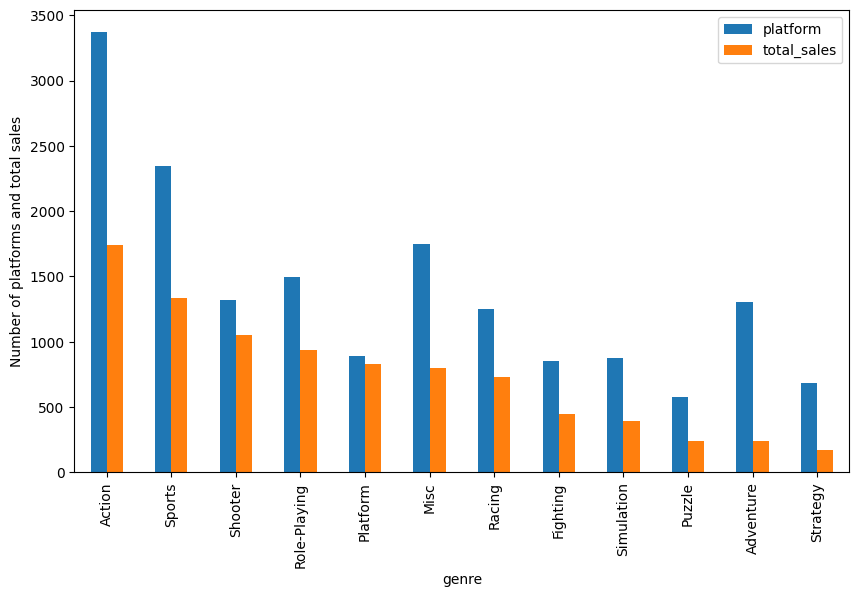

In [70]:
genre_games.plot(figsize=(10, 6), kind="bar", x="genre", y=["platform", "total_sales"], ylabel="Number of platforms and total sales")
plt.show()

Los generos mas cotizados, son los que mas se venden, y no necesariamente tienen la calificacion critica mas alta. La calificacion critica destaca y ayuda a que un juego sobre salga del resto en base a la experiencia de juego "corta" que tienen dichos criticos, pero sin definir si los usuarios les vaya a gustar o no. Puede ser que un juego o un genero tenga una calificacion decente de "critic_score" pero no necesariamente tendria la misma calificacion de parte de los usuarios, porque los usuarios viven la experiencia completa y no tienen un criterio como el de los criticos; simplemente lo disfrutan y les gusta sin necesidad de analizarlo criticamente, por lo que tendria una calificacion mas alta o mas baja por parte de los usuarios por como lo disfrutan o no.

El factor prioritario de saber si un juego va tener tener ventas o no, la definen las personas/usuarios que lo experimenten, si les gusta o no a los usuarios y no necesariamente a los criticos. Existen generos o juegos que podran tener calificacion baja de parte de los criticos y calificacion mas alta de parte de los que lo compran y lo juegan; eso seria lo que realmente importa para evaluar la experiencia y la satisfaccion a la hora de jugarlo. Como consumidor te ha una idea bastante cercana de como tu podrias vivir esa experiencia, ya que son opiniones de usuarios interesados en lo mismo que tu.

Se aprecia mediante el analisis que hice, que "user_score" tiende a ser mas alta que "critic_score" para los juegos que tiene mas ventas, por lo que se puede decir que la calificacion de los consumidores es lo que realmente define si va tener ventas altas o no.

In [71]:
# Paso 4. Crea un perfil de usuario para cada región

# Para cada región (NA, UE, JP) determina:

In [72]:
na_games = games.groupby("platform").agg({"na_sales": "sum",
                            "name": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("na_sales", ascending=False)

na_games

,platform,na_sales,name,total_sales,critic_score,user_score
28,X360,602.47,1262,971.42,68.616812,6.683540
16,PS2,583.84,2161,1255.77,68.727273,7.626833
26,Wii,496.90,1320,907.51,62.823932,6.742679
17,PS3,393.49,1331,939.65,70.382927,6.726568
4,DS,382.40,2151,806.12,63.761506,7.025194
15,PS,336.52,1197,730.86,71.515,7.865432
6,GBA,187.54,822,317.85,67.372146,7.676863
29,XB,186.69,824,257.74,69.85931,7.500512
10,N64,139.02,319,218.68,<NA>,NaN
7,GC,133.46,556,198.93,69.488839,7.597541


In [73]:
eu_games = games.groupby("platform").agg({"eu_sales": "sum",
                            "name": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("eu_sales", ascending=False)

eu_games

,platform,eu_sales,name,total_sales,critic_score,user_score
16,PS2,339.29,2161,1255.77,68.727273,7.626833
17,PS3,330.29,1331,939.65,70.382927,6.726568
28,X360,270.76,1262,971.42,68.616812,6.683540
26,Wii,262.21,1320,907.51,62.823932,6.742679
15,PS,213.61,1197,730.86,71.515,7.865432
4,DS,188.89,2151,806.12,63.761506,7.025194
13,PC,142.44,974,259.52,75.928671,7.062468
18,PS4,141.09,392,314.14,72.09127,6.748249
6,GBA,75.25,822,317.85,67.372146,7.676863
19,PSP,66.68,1209,294.05,67.424242,7.228266


In [74]:
jp_games = games.groupby("platform").agg({"jp_sales": "sum",
                            "name": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("jp_sales", ascending=False)

jp_games

,platform,jp_sales,name,total_sales,critic_score,user_score
4,DS,175.57,2151,806.12,63.761506,7.025194
15,PS,139.82,1197,730.86,71.515,7.865432
16,PS2,139.20,2161,1255.77,68.727273,7.626833
23,SNES,116.55,239,200.04,<NA>,NaN
2,3DS,100.67,520,259.00,67.10119,6.831609
11,NES,98.65,98,251.05,<NA>,NaN
5,GB,85.12,98,255.46,<NA>,NaN
17,PS3,80.19,1331,939.65,70.382927,6.726568
19,PSP,76.78,1209,294.05,67.424242,7.228266
26,Wii,69.33,1320,907.51,62.823932,6.742679


In [75]:
# Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.

In [76]:
print("Top 5 plataformas en North America:")
na_top5 = na_games[["platform", "na_sales", "name", "total_sales"]].head(5)

na_top5

Top 5 plataformas en North America:


,platform,na_sales,name,total_sales
28,X360,602.47,1262,971.42
16,PS2,583.84,2161,1255.77
26,Wii,496.90,1320,907.51
17,PS3,393.49,1331,939.65
4,DS,382.40,2151,806.12


In [77]:
print("Top 5 plataformas en Europe:")
eu_top5 = eu_games[["platform", "eu_sales", "name", "total_sales"]].head(5)

eu_top5

Top 5 plataformas en Europe:


,platform,eu_sales,name,total_sales
16,PS2,339.29,2161,1255.77
17,PS3,330.29,1331,939.65
28,X360,270.76,1262,971.42
26,Wii,262.21,1320,907.51
15,PS,213.61,1197,730.86


In [78]:
print("Top 5 plataformas en Japan:")
jp_top5 = jp_games[["platform", "jp_sales", "name", "total_sales"]].head(5)

jp_top5

Top 5 plataformas en Japan:


,platform,jp_sales,name,total_sales
4,DS,175.57,2151,806.12
15,PS,139.82,1197,730.86
16,PS2,139.20,2161,1255.77
23,SNES,116.55,239,200.04
2,3DS,100.67,520,259.00


Hay gran variacion de las ventas de cada plataforma en diferentes regiones. Se aprecia que x360, PS, PS2 predoniman en el mercado Norte americano y europeo, son lideres en ventas aparte de ser los que mas juegos tienen. El de mayores ventas en general es PS2, abarcando el consumo mas frecuente en video juegos en todo el mundo. Al parece en el mercado europeo es mas consistente las ventas de la compañia de PS, a diferencia que en norte amnerica que predomina las ventas de X360.

In [79]:
# Los cinco géneros principales. Explica la diferencia.
# Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [80]:
na_genre = games.groupby("genre").agg({"na_sales": "sum",
                           "rating": "count",
                           "platform": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("na_sales", ascending=False)
na_genre

,genre,na_sales,rating,platform,total_sales,critic_score,user_score
0,Action,879.01,2188,3369,1744.17,66.629101,7.054044
10,Sports,684.43,1509,2348,1331.27,71.968174,6.961197
8,Shooter,592.24,1019,1323,1052.45,70.181144,7.041883
4,Platform,445.50,569,888,827.77,68.05835,7.301402
3,Misc,407.27,882,1750,802.51,66.619503,6.819362
6,Racing,359.35,872,1249,728.67,67.963612,7.036193
7,Role-Playing,330.81,777,1498,934.56,72.652646,7.619515
2,Fighting,223.36,438,849,447.53,69.217604,7.302506
9,Simulation,181.92,568,873,389.97,68.619318,7.134593
5,Puzzle,122.87,342,580,242.57,67.424107,7.175000


In [81]:
eu_genre = games.groupby("genre").agg({"eu_sales": "sum",
                           "rating": "count",
                           "platform": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("eu_sales", ascending=False)
eu_genre

,genre,eu_sales,rating,platform,total_sales,critic_score,user_score
0,Action,519.13,2188,3369,1744.17,66.629101,7.054044
10,Sports,376.79,1509,2348,1331.27,71.968174,6.961197
8,Shooter,317.34,1019,1323,1052.45,70.181144,7.041883
6,Racing,236.51,872,1249,728.67,67.963612,7.036193
3,Misc,212.74,882,1750,802.51,66.619503,6.819362
4,Platform,200.35,569,888,827.77,68.05835,7.301402
7,Role-Playing,188.71,777,1498,934.56,72.652646,7.619515
9,Simulation,113.52,568,873,389.97,68.619318,7.134593
2,Fighting,100.33,438,849,447.53,69.217604,7.302506
1,Adventure,63.54,446,1303,237.59,65.331269,7.133000


In [82]:
jp_genre = games.groupby("genre").agg({"jp_sales": "sum",
                           "rating": "count",
                           "platform": "count",
                           "total_sales": "sum",
                           "critic_score": "mean",
                           "user_score": "mean"}).reset_index().sort_values("jp_sales", ascending=False)
jp_genre

,genre,jp_sales,rating,platform,total_sales,critic_score,user_score
7,Role-Playing,355.41,777,1498,934.56,72.652646,7.619515
0,Action,161.43,2188,3369,1744.17,66.629101,7.054044
10,Sports,135.54,1509,2348,1331.27,71.968174,6.961197
4,Platform,130.83,569,888,827.77,68.05835,7.301402
3,Misc,108.11,882,1750,802.51,66.619503,6.819362
2,Fighting,87.48,438,849,447.53,69.217604,7.302506
9,Simulation,63.80,568,873,389.97,68.619318,7.134593
5,Puzzle,57.31,342,580,242.57,67.424107,7.175000
6,Racing,56.71,872,1249,728.67,67.963612,7.036193
1,Adventure,52.30,446,1303,237.59,65.331269,7.133000


In [83]:
esrb_analysis = games.groupby('rating').agg({
    'na_sales': 'sum',
    'eu_sales': 'sum',
    'jp_sales': 'sum',
    'total_sales': 'sum'
}).reset_index().sort_values("total_sales", ascending=False)

esrb_analysis

,rating,na_sales,eu_sales,jp_sales,total_sales
1,E,1292.99,710.25,198.11,2435.52
7,T,759.75,427.03,151.40,1493.35
5,M,748.48,483.97,64.24,1473.79
2,E10+,353.32,188.52,40.20,655.60
4,K-A,2.56,0.27,1.46,4.32
0,AO,1.26,0.61,0.00,1.96
3,EC,1.53,0.11,0.00,1.75
6,RP,0.00,0.08,0.00,0.09


La diferencia de los generos principales de cada region radica en los gustos y preferencias a los que los usuarios acostumbran. Por ejemplo en japon se aprecia que el genero de "shooter" es el mas bajo cuando en las otras 2 regiones esta en el top 3 generos mas cotizados.

Los generos que siempre destacan son "accion" y "deportes"; pero accion lidera en las 2 posiciones principales de las 3 regiones. Para asegurar el exito de la plataforma o de algun juegon, se tiene que considerar bastante, de que genero se va a tratar para establecer un unmbral de ventas mas alto que los otros generos, aunque no definiria si va a tener exito o no; simplemente es tener mas probabildades de mayor ventas por el tipod de genero que llegue a ser.

Las clasificaciones tambien varian conforme las regiulaciones establecidas para cada pais o region. La clasificacion mas cotizada, es la que es para todo publico; por ende va tener mas ventas en general y de cada region; es sencillo inferir eso, pero no pasa lo mismo con la clasificacion "E+10". Uno esperaria, siguiendo la misma logica, que esta clasificacion seria la mas cotizafa despues de "E" pero no funciona asi. La siguiente clasificacion es "T", por lo que se entiende que es la segunda mas cotizada, ya que abarca varios juegos de deportes y algunos de accion; siendo el genero de "deportes" uno de los mas cotizados; se entiende, aparte de que hay mas personas que pueden jugar este juego, y como normalmente los niños son un mercado escencial, se entiende que es de los mas cotizados.

Las clasificaciones si afectan pero no escencialmente las ventas del juego o genero, si no que al tener de prospecto un juego de accion que es por ejemplo "M" de mature, osea arriba de 17 años; tendras menos posibildad de que mas usuarios lo jueguen, ya que privas de jugar a los que tienen menos edad y por razon logica, hay menos usuarios que tienen la opcion de jugarlo a diferencia de un juego que es para todos "E".

In [84]:
# Paso 5. Prueba las siguientes hipótesis:

# Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [85]:
xbox_one = games[(games["platform"] == "XOne") & (games["user_score"].notna())]["user_score"]

xbox_one

165      7.9
179      5.4
242      6.4
270      6.2
373      4.1
        ... 
16544    6.8
16597    6.0
16630    8.2
16643    6.6
16660    6.7
Name: user_score, Length: 182, dtype: float64

In [86]:
pc = games[(games["platform"] == "PC") & (games["user_score"].notna())]["user_score"]

pc

85       7.6
138      7.3
192      4.0
218      8.2
284      9.1
        ... 
16681    8.1
16692    7.6
16696    5.8
16702    7.2
16705    5.8
Name: user_score, Length: 770, dtype: float64

In [87]:
alpha = 0.05

In [88]:
results_platform = stats.ttest_ind(xbox_one, pc, equal_var=False)
p_value_platform = results_platform.pvalue

p_value_platform

np.float64(4.935072360183574e-06)

In [89]:
if p_value_platform > alpha:
    print("no podemos rechazar la hipotesis nula")
else:
    print("rechazamos la hipotesis nula")

rechazamos la hipotesis nula


Se rechaza la hipotesis nula debido a que SI exite una diferencia significativa en las calificaciones promedio de los usuarios de Xbox One y PC. En definicion, no tienen el mismo promedio de calificaciones, es lo suficientemente diferente como para descartar que sean iguales. La hipotesis alternativa se cumple "Hay diferencia en las calificaciones promedio de los usuarios entre XboxOne y PC" (Umbral de diferencia es de 5%)

In [90]:
action = games[(games["genre"] == "Action") & (games["user_score"].notna())]["user_score"]

In [91]:
sports = games[(games["genre"] == "Sports") & (games["user_score"].notna())]["user_score"]

In [92]:
alpha = 0.05

In [93]:
results_genre = stats.ttest_ind(action, sports, equal_var=False)
p_value_genre = results_genre.pvalue

p_value_genre

np.float64(0.11483818791498286)

In [94]:
if p_value_genre > alpha:
    print("no podemos rechazar la hipotesis nula")
else:
    print("rechazamos la hipotesis nula")

no podemos rechazar la hipotesis nula


El resultado de esta prueba de hipotesis infiere a que las calificaciones promedio para los genres de accion y deportes son casi las mismas, de acuerdo al rango de diferencia significativa. No se puede rechazar la hipotesis nula, ya que el valor "p_value" es mayor que el umbral de "alpha"; no tiene una significancia estadistica sufiente como para decir que el promedio de calificacion entre estos dos generos sea diferente, por lo tanto no se rechaza la hipotesis nula, justo porque son muy parecidas las medias de calificaciones en promedio.

In [95]:
# Paso 6. Escribe una conclusión general

Mediante el analisis general del proyecto, es importante destacar que el proposito es sustentar de manera estadistica comprobable, los patrones que reafirmen si un juego tiene exito o no, de los datos de los juegos de cada plataforma del 2016, pensado en campañas publicitarias para 2017.

Pude verificar que los juegos que no tuvieron calificacion critica de acuerdo al año, infiere a que son juegos de una epoca en especifico. No son tan viejos pero tampoco tan nuevos; esa epoca esta entre 2007 y 2011, por lo que se podria intuir que no hubo calificacion criticas porque no son juegos de años recientes, aparte de que podria influir por la plataforma o porque no alcanzaron un numero conveniente de ventas en general. Las calificaciones criticas es un factor que influye bastante en cuanto a que tan cotizado puede llegar a ser un juego, un genero o una plataforma. Mas adelante, por medio de analisis mas profundo, se podra corroborar este factor.

Las plataformas que contienen mas juegos con valores ausentes en "critic_score", se puede inferir a que son plataformas retro, mas no las mas viejas; eso puede influir en que no se haya tomado en cuenta la necesidad de calificarlos criticamente, sin descartar el hecho de que tambien pueden ser juegos mas independientes, por lo que no se invirtio mucho dinero, de parte de compañias con bajo prestigio como para tener tantas ventas.

La epoca dorada de los videojuegos en general influyo en un rango de años de 2006 a 2011, se puede observar este hecho mediante los graficos visuales, de acuerdo a los datos de "year_of_release".




Por medio del analisis de distribución de ventas totales por plataforma, se puede notar una gran diferencia de ciertos juegos que alcanzaron mayor exito en ventas, los cuales se consideran valores atipicos; esto se puede observar en el grafico de caja que hice referente a las ventas totales por plataforma.

La media sin embargo es de 287 millones cuando el valor maximo es de 1255 millones, por lo que es muy grande la diferencia del promedio. Las consolas mas populares y que todos conocemos establecen ser las unicas que cumplen con las expectativas de los clientes, debido a que superaron con creces las ventas totales de juegos de otras plataformas que estan conforme a la media. La media se dispara bastante a diferencia de la mediana por el sesgo que crean los valores atipicos ya mecionados.


Por otro lado tambien se pueden observar que entre mas puntuacion alta critica, mas cotizados y vendidos seran seran los juegos, sin que necesariamente necesiten un puntaje alto para destacar en ventas.

Muchos de los juegos de calificaciones de usuarios altas no necesariamente tienen ventan que destaquen, de hecho muchos de ellos que obtuvieron entre 9 y 10 de "user_score" tienen menos de 20 millones de ventas totales, habiendo juegos de entre 6 a 8 de "user_score" que superan facilmente los 20 millomnes en ventas totales. Significa que no necesariamente que la mas alta calificacion de usuario hara que sea de los mas cotizados para los usuarios en general.

Los juegos con valores ausentes de parte de calificaciones de usuarios y de criticos son muy importantes en relacion con la cantidad de ventas totales que se obtengan de esos juegos. Se aprecia la manera en la que los juegos con valores ausentes en "user_score" y "critic_score" de la plataforma de "xbox360" no tiene casi ventas en comparacion a los juegos que si tiene califacion critica y de usuario. En definicion, los juegos con valores ausentes en calificaciones, afecta de manera alarmante las ventas totales de dichos juegos.

Los generos mas cotizados, son los que mas se venden, y no necesariamente tienen la calificacion critica mas alta. La calificacion critica destaca y ayuda a que un juego sobre salga del resto en base a la experiencia de juego "corta" que tienen dichos criticos, pero sin definir si los usuarios les vaya a gustar o no. Puede ser que un juego o un genero tenga una calificacion decente de "critic_score" pero no necesariamente tendria la misma calificacion de parte de los usuarios, porque los usuarios viven la experiencia completa y no tienen un criterio como el de los criticos; simplemente lo disfrutan y les gusta sin necesidad de analizarlo criticamente, por lo que tendria una calificacion mas alta o mas baja por parte de los usuarios por como lo disfrutan o no.

El factor prioritario de saber si un juego va tener tener ventas o no, la definen las personas/usuarios que lo experimenten, si les gusta o no a los usuarios y no necesariamente a los criticos. Existen generos o juegos que podran tener calificacion baja de parte de los criticos y calificacion mas alta de parte de los que lo compran y lo juegan; eso seria lo que realmente importa para evaluar la experiencia y la satisfaccion a la hora de jugarlo. Como consumidor te ha una idea bastante cercana de como tu podrias vivir esa experiencia, ya que son opiniones de usuarios interesados en lo mismo que tu.

Se aprecia mediante el analisis que hice, que "user_score" tiende a ser mas alta que "critic_score" para los juegos que tiene mas ventas, por lo que se puede decir que la calificacion de los consumidores es lo que realmente define si va tener ventas altas o no.

La diferencia de los generos principales de cada region radica en los gustos y preferencias a los que los usuarios acostumbran. Por ejemplo en japon se aprecia que el genero de "shooter" es el mas bajo cuando en las otras 2 regiones esta en el top 3 generos mas cotizados.

Los generos que siempre destacan son "accion" y "deportes"; pero accion lidera en las 2 posiciones principales de las 3 regiones. Para asegurar el exito de la plataforma o de algun juegon, se tiene que considerar bastante, de que genero se va a tratar para establecer un unmbral de ventas mas alto que los otros generos, aunque no definiria si va a tener exito o no; simplemente es tener mas probabildades de mayor ventas por el tipod de genero que llegue a ser.

Las clasificaciones si afectan pero no escencialmente las ventas del juego o genero, si no que al tener de prospecto un juego de accion que es por ejemplo "M" de mature, osea arriba de 17 años; tendras menos posibildad de que mas usuarios lo jueguen, ya que privas de jugar a los que tienen menos edad y por razon logica, hay menos usuarios que tienen la opcion de jugarlo a diferencia de un juego que es para todos "E".